In [1]:
# cell 1
# Install and import lightweight dependencies for KG analysis and plotting.

!pip -q install -U torch-geometric tqdm numpy pandas matplotlib psutil

import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch_geometric.data import HeteroData

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cpu
CUDA available: False


In [2]:
# cell 2
# Mount Google Drive and define only the required KG paths.
# Nothing will be saved in this notebook.

from google.colab import drive
drive.mount("/content/drive")

DATASET = "hotpotqa"

PROJECT_DIR = Path("/content/drive/MyDrive/final_project/idea_1")
DATASET_DIR = PROJECT_DIR / "kg" / DATASET
CONSTRUCT_DIR = DATASET_DIR / "kg_construct"

HETERO_KG_PT_PATH = CONSTRUCT_DIR / "hotpotqa_hetero_kg.pt"
KG_META_JSON_PATH = CONSTRUCT_DIR / "hotpotqa_hetero_kg_meta.json"

ENTITY_NODES_JSONL_PATH = CONSTRUCT_DIR / "hotpotqa_entity_nodes_for_kg.jsonl"
CHUNK_TEXT_CATALOG_JSONL_PATH = CONSTRUCT_DIR / "hotpotqa_chunk_text_catalog.jsonl"

required_paths = [
    HETERO_KG_PT_PATH,
    KG_META_JSON_PATH,
    ENTITY_NODES_JSONL_PATH,
    CHUNK_TEXT_CATALOG_JSONL_PATH,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")

print("KG path:", HETERO_KG_PT_PATH)
print("Meta path:", KG_META_JSON_PATH)

Mounted at /content/drive
KG path: /content/drive/MyDrive/final_project/idea_1/kg/hotpotqa/kg_construct/hotpotqa_hetero_kg.pt
Meta path: /content/drive/MyDrive/final_project/idea_1/kg/hotpotqa/kg_construct/hotpotqa_hetero_kg_meta.json


In [3]:
# cell 3
# Load the saved PyG heterogeneous KG and metadata.

kg = torch.load(HETERO_KG_PT_PATH, map_location="cpu", weights_only=False)

with open(KG_META_JSON_PATH, "r", encoding="utf-8") as f:
    kg_meta = json.load(f)

print(kg)

print("\nNode types:", kg.node_types)
print("Edge types:", kg.edge_types)

num_entities = int(kg["entity"].num_nodes)
num_chunks = int(kg["chunk"].num_nodes)

print("\nNumber of entity nodes:", num_entities)
print("Number of chunk nodes:", num_chunks)

HeteroData(
  entity={
    num_nodes=327873,
    entity_id=[327873],
  },
  chunk={
    num_nodes=35029,
    chunk_node_id=[35029],
  },
  (entity, relation, entity)={
    edge_index=[2, 692402],
    relation_id=[692402],
    chunk_node_id=[692402],
  },
  (entity, fact, chunk)={
    edge_index=[2, 559959],
    fact_id=[559959],
  },
  (chunk, next_chunk, chunk)={ edge_index=[2, 25219] },
  (chunk, prev_chunk, chunk)={ edge_index=[2, 25219] }
)

Node types: ['entity', 'chunk']
Edge types: [('entity', 'relation', 'entity'), ('entity', 'fact', 'chunk'), ('chunk', 'next_chunk', 'chunk'), ('chunk', 'prev_chunk', 'chunk')]

Number of entity nodes: 327873
Number of chunk nodes: 35029


In [4]:
# cell 4
# Define helper functions for degree computation and plotting.

def to_numpy_tensor(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def bincount_nodes(indices, num_nodes):
    indices = to_numpy_tensor(indices).astype(np.int64)
    return np.bincount(indices, minlength=num_nodes).astype(np.int64)


def describe_degree_array(values):
    values = np.asarray(values, dtype=np.int64)
    positive = values[values > 0]

    stats = {
        "num_nodes": int(values.size),
        "zero_degree_nodes": int((values == 0).sum()),
        "nonzero_degree_nodes": int((values > 0).sum()),
        "min": int(values.min()),
        "max": int(values.max()),
        "mean": float(values.mean()),
        "median": float(np.median(values)),
        "p90": float(np.percentile(values, 90)),
        "p95": float(np.percentile(values, 95)),
        "p99": float(np.percentile(values, 99)),
    }

    if positive.size > 0:
        stats.update({
            "positive_min": int(positive.min()),
            "positive_mean": float(positive.mean()),
            "positive_median": float(np.median(positive)),
            "positive_p90": float(np.percentile(positive, 90)),
            "positive_p95": float(np.percentile(positive, 95)),
            "positive_p99": float(np.percentile(positive, 99)),
        })

    return stats


def show_stats_table(title, stats_dict):
    print(title)
    display(pd.DataFrame([stats_dict]).T.rename(columns={0: "value"}))


def plot_log_hist(values, title, xlabel, bins=80):
    values = np.asarray(values, dtype=np.int64)
    positive = values[values > 0]
    zero_count = int((values == 0).sum())

    if positive.size == 0:
        raise RuntimeError(f"No positive values to plot for: {title}")

    max_value = int(positive.max())
    bin_edges = np.logspace(0, np.log10(max_value + 1), bins)

    plt.figure(figsize=(9, 6))
    plt.hist(positive, bins=bin_edges)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("Number of nodes")
    plt.title(f"{title}\nzero-degree nodes: {zero_count:,}")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()


def plot_linear_hist(values, title, xlabel, bins=80, log_y=True):
    values = np.asarray(values, dtype=np.int64)

    plt.figure(figsize=(9, 6))
    plt.hist(values, bins=bins)

    if log_y:
        plt.yscale("log")

    plt.xlabel(xlabel)
    plt.ylabel("Number of nodes")
    plt.title(title)
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.show()

In [5]:
# cell 5
# Compute degree arrays for entity nodes and chunk nodes.

rel_edge_index = kg[("entity", "relation", "entity")].edge_index
fact_edge_index = kg[("entity", "fact", "chunk")].edge_index
next_edge_index = kg[("chunk", "next_chunk", "chunk")].edge_index
prev_edge_index = kg[("chunk", "prev_chunk", "chunk")].edge_index

# Entity degrees.
entity_relation_out_degree = bincount_nodes(rel_edge_index[0], num_entities)
entity_relation_in_degree = bincount_nodes(rel_edge_index[1], num_entities)
entity_fact_out_degree = bincount_nodes(fact_edge_index[0], num_entities)

entity_relation_total_degree = entity_relation_out_degree + entity_relation_in_degree

entity_total_degree = (
    entity_relation_out_degree
    + entity_relation_in_degree
    + entity_fact_out_degree
)

# Chunk degrees.
chunk_fact_in_degree = bincount_nodes(fact_edge_index[1], num_chunks)

# Use next_chunk as undirected adjacency to avoid double-counting prev_chunk.
chunk_sequence_neighbor_degree = (
    bincount_nodes(next_edge_index[0], num_chunks)
    + bincount_nodes(next_edge_index[1], num_chunks)
)

chunk_total_degree = chunk_fact_in_degree + chunk_sequence_neighbor_degree

# Extra diagnostic degrees.
chunk_next_out_degree = bincount_nodes(next_edge_index[0], num_chunks)
chunk_next_in_degree = bincount_nodes(next_edge_index[1], num_chunks)
chunk_prev_out_degree = bincount_nodes(prev_edge_index[0], num_chunks)
chunk_prev_in_degree = bincount_nodes(prev_edge_index[1], num_chunks)

chunk_stored_sequence_directed_degree = (
    chunk_next_out_degree
    + chunk_next_in_degree
    + chunk_prev_out_degree
    + chunk_prev_in_degree
)

print("Degree arrays computed.")

print("\nSanity checks:")
print("Relation edges:", int(rel_edge_index.shape[1]))
print("Sum relation out-degree:", int(entity_relation_out_degree.sum()))
print("Sum relation in-degree :", int(entity_relation_in_degree.sum()))

print("\nFact edges:", int(fact_edge_index.shape[1]))
print("Sum entity fact out-degree:", int(entity_fact_out_degree.sum()))
print("Sum chunk fact in-degree  :", int(chunk_fact_in_degree.sum()))

print("\nNext chunk edges:", int(next_edge_index.shape[1]))
print("Prev chunk edges:", int(prev_edge_index.shape[1]))
print("Sum chunk sequence neighbor degree:", int(chunk_sequence_neighbor_degree.sum()))
print("Expected 2 * next_chunk edges:", int(2 * next_edge_index.shape[1]))

Degree arrays computed.

Sanity checks:
Relation edges: 692402
Sum relation out-degree: 692402
Sum relation in-degree : 692402

Fact edges: 559959
Sum entity fact out-degree: 559959
Sum chunk fact in-degree  : 559959

Next chunk edges: 25219
Prev chunk edges: 25219
Sum chunk sequence neighbor degree: 50438
Expected 2 * next_chunk edges: 50438


In [6]:
# cell 6
# Show a compact KG summary table.

kg_summary_df = pd.DataFrame([
    {"item": "entity nodes", "count": num_entities},
    {"item": "chunk nodes", "count": num_chunks},
    {"item": "entity-relation-entity edges", "count": int(rel_edge_index.shape[1])},
    {"item": "entity-fact-chunk edges", "count": int(fact_edge_index.shape[1])},
    {"item": "chunk-next_chunk-chunk edges", "count": int(next_edge_index.shape[1])},
    {"item": "chunk-prev_chunk-chunk edges", "count": int(prev_edge_index.shape[1])},
])

display(kg_summary_df)

,item,count
0,entity nodes,327873
1,chunk nodes,35029
2,entity-relation-entity edges,692402
3,entity-fact-chunk edges,559959
4,chunk-next_chunk-chunk edges,25219
5,chunk-prev_chunk-chunk edges,25219


In [7]:
# cell 7
# Show degree statistics as tables.

show_stats_table(
    "Entity total degree = relation_out + relation_in + fact_out",
    describe_degree_array(entity_total_degree),
)

show_stats_table(
    "Entity relation degree = relation_out + relation_in",
    describe_degree_array(entity_relation_total_degree),
)

show_stats_table(
    "Entity fact-out degree",
    describe_degree_array(entity_fact_out_degree),
)

show_stats_table(
    "Chunk total degree = fact_in + sequence_neighbor_degree",
    describe_degree_array(chunk_total_degree),
)

show_stats_table(
    "Chunk fact-in degree",
    describe_degree_array(chunk_fact_in_degree),
)

show_stats_table(
    "Chunk sequence neighbor degree",
    describe_degree_array(chunk_sequence_neighbor_degree),
)

Entity total degree = relation_out + relation_in + fact_out


,value
num_nodes,327873.000000
zero_degree_nodes,0.000000
nonzero_degree_nodes,327873.000000
min,1.000000
max,4378.000000
mean,5.931452
median,2.000000
p90,9.000000
p95,17.000000
p99,62.000000


Entity relation degree = relation_out + relation_in


,value
num_nodes,327873.000000
zero_degree_nodes,5433.000000
nonzero_degree_nodes,322440.000000
min,0.000000
max,3374.000000
mean,4.223599
median,1.000000
p90,7.000000
p95,12.000000
p99,46.000000


Entity fact-out degree


...

,value
num_nodes,35029.000000
zero_degree_nodes,2.000000
nonzero_degree_nodes,35027.000000
min,0.000000
max,32.000000
mean,17.425476
median,17.000000
p90,26.000000
p95,28.000000
p99,32.000000


Chunk fact-in degree


,value
num_nodes,35029.000000
zero_degree_nodes,22.000000
nonzero_degree_nodes,35007.000000
min,0.000000
max,30.000000
mean,15.985583
median,15.000000
p90,24.000000
p95,27.000000
p99,30.000000


Chunk sequence neighbor degree


,value
num_nodes,35029.000000
zero_degree_nodes,4586.000000
nonzero_degree_nodes,30443.000000
min,0.000000
max,2.000000
mean,1.439893
median,2.000000
p90,2.000000
p95,2.000000
p99,2.000000


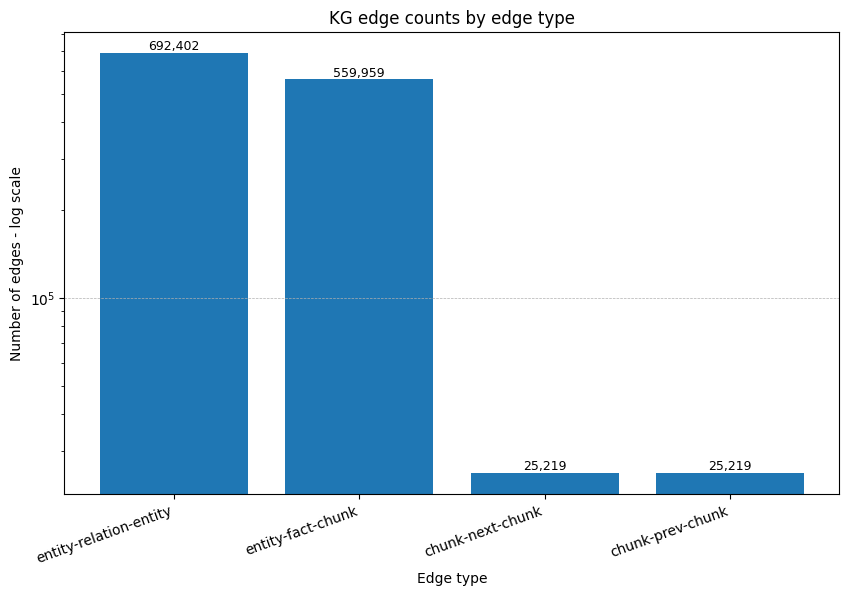

In [8]:
# cell 8
# Plot edge counts by edge type.

edge_type_names = [
    "entity-relation-entity",
    "entity-fact-chunk",
    "chunk-next-chunk",
    "chunk-prev-chunk",
]

edge_type_counts = [
    int(rel_edge_index.shape[1]),
    int(fact_edge_index.shape[1]),
    int(next_edge_index.shape[1]),
    int(prev_edge_index.shape[1]),
]

plt.figure(figsize=(10, 6))
plt.bar(edge_type_names, edge_type_counts)
plt.yscale("log")
plt.xlabel("Edge type")
plt.ylabel("Number of edges - log scale")
plt.title("KG edge counts by edge type")
plt.xticks(rotation=20, ha="right")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5)

for i, count in enumerate(edge_type_counts):
    plt.text(i, count, f"{count:,}", ha="center", va="bottom", fontsize=9)

plt.show()

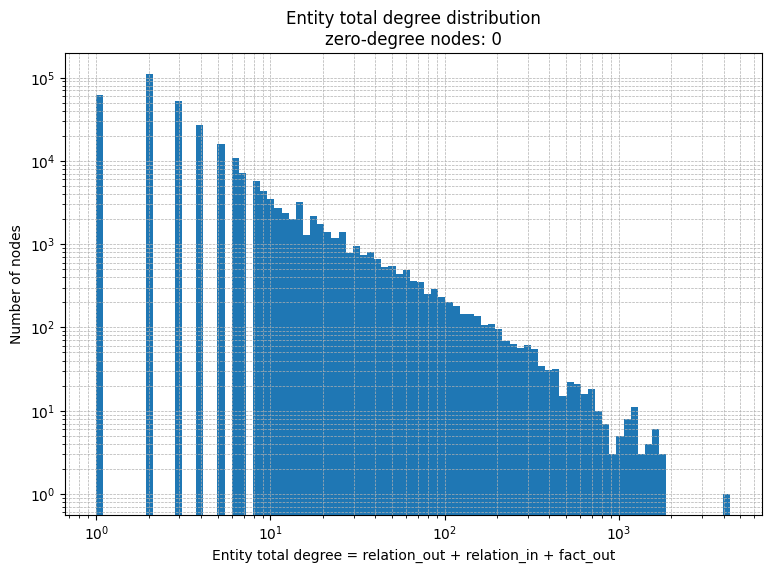

In [9]:
# cell 9
# Plot histogram of total entity degree.
# total entity degree = relation_out + relation_in + fact_out.

plot_log_hist(
    values=entity_total_degree,
    title="Entity total degree distribution",
    xlabel="Entity total degree = relation_out + relation_in + fact_out",
    bins=90,
)

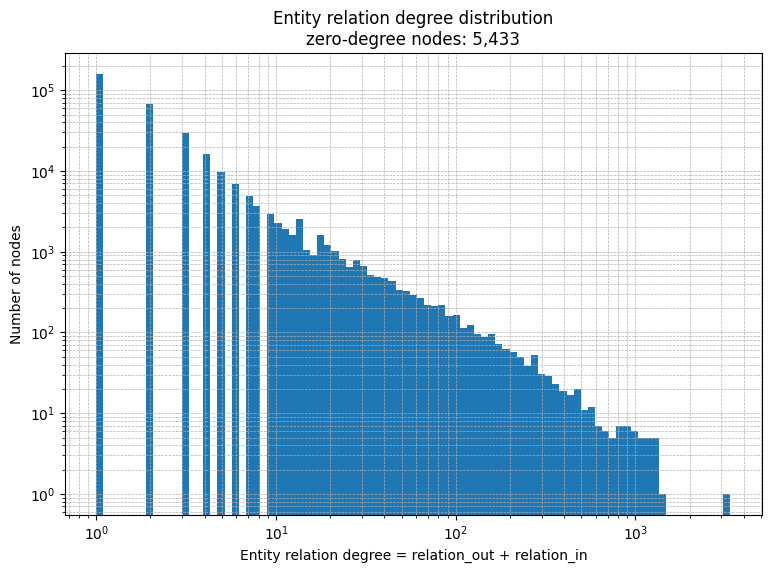

In [10]:
# cell 10
# Plot histogram of entity relation degree.
# relation degree = relation_out + relation_in.

plot_log_hist(
    values=entity_relation_total_degree,
    title="Entity relation degree distribution",
    xlabel="Entity relation degree = relation_out + relation_in",
    bins=90,
)

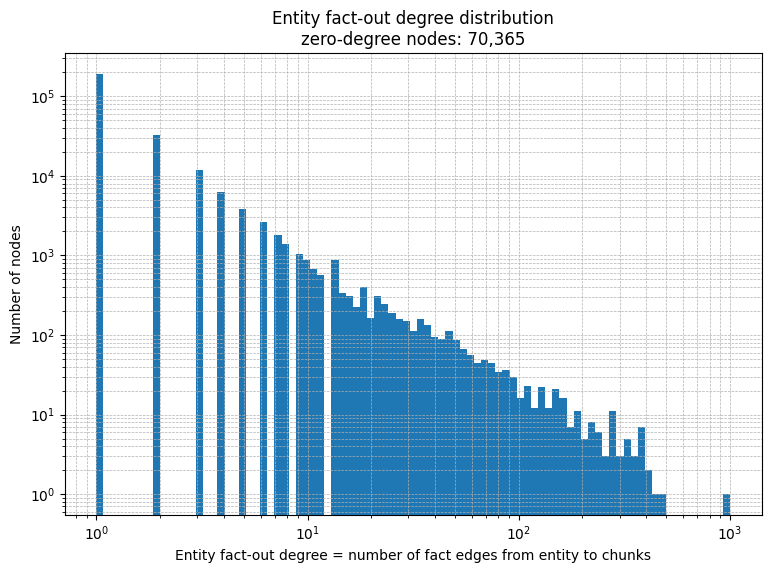

In [11]:
# cell 11
# Plot histogram of entity fact-out degree.

plot_log_hist(
    values=entity_fact_out_degree,
    title="Entity fact-out degree distribution",
    xlabel="Entity fact-out degree = number of fact edges from entity to chunks",
    bins=90,
)

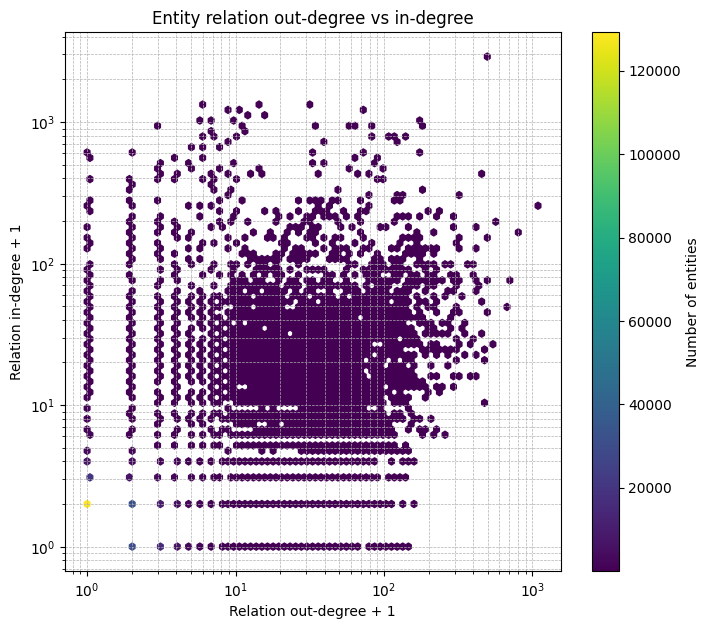

In [12]:
# cell 12
# Plot relation in-degree vs relation out-degree for entity nodes.

positive_mask = (entity_relation_in_degree + entity_relation_out_degree) > 0

x = entity_relation_out_degree[positive_mask]
y = entity_relation_in_degree[positive_mask]

plt.figure(figsize=(8, 7))
plt.hexbin(x + 1, y + 1, gridsize=80, xscale="log", yscale="log", mincnt=1)
plt.xlabel("Relation out-degree + 1")
plt.ylabel("Relation in-degree + 1")
plt.title("Entity relation out-degree vs in-degree")
plt.colorbar(label="Number of entities")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()

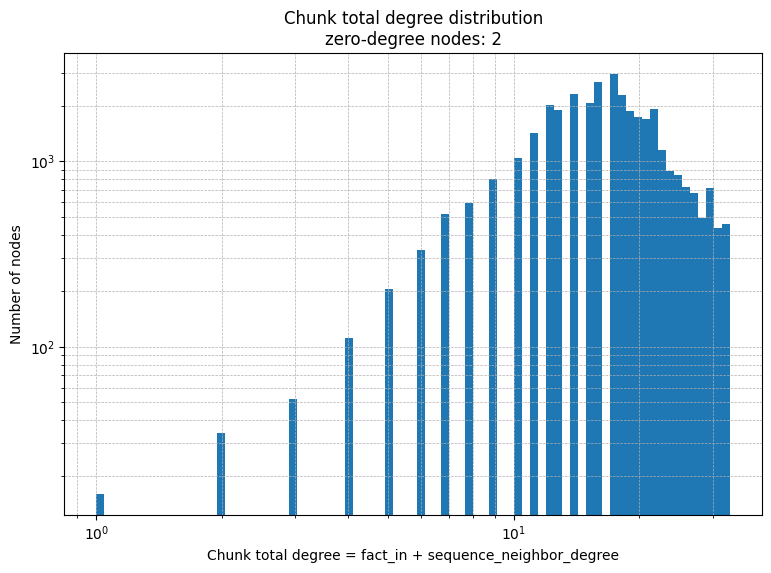

In [13]:
# cell 13
# Plot histogram of total chunk degree.
# chunk total degree = fact_in + sequence_neighbor_degree.

plot_log_hist(
    values=chunk_total_degree,
    title="Chunk total degree distribution",
    xlabel="Chunk total degree = fact_in + sequence_neighbor_degree",
    bins=80,
)

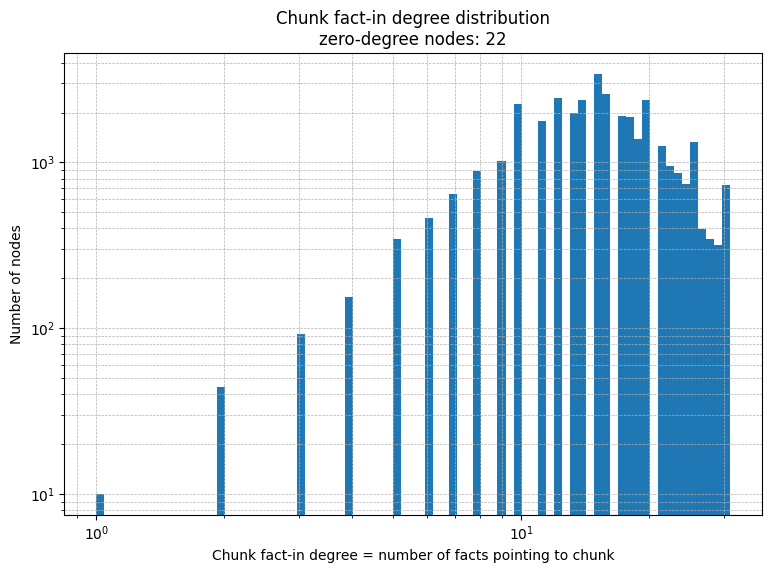

In [14]:
# cell 14
# Plot histogram of chunk fact-in degree.

plot_log_hist(
    values=chunk_fact_in_degree,
    title="Chunk fact-in degree distribution",
    xlabel="Chunk fact-in degree = number of facts pointing to chunk",
    bins=80,
)

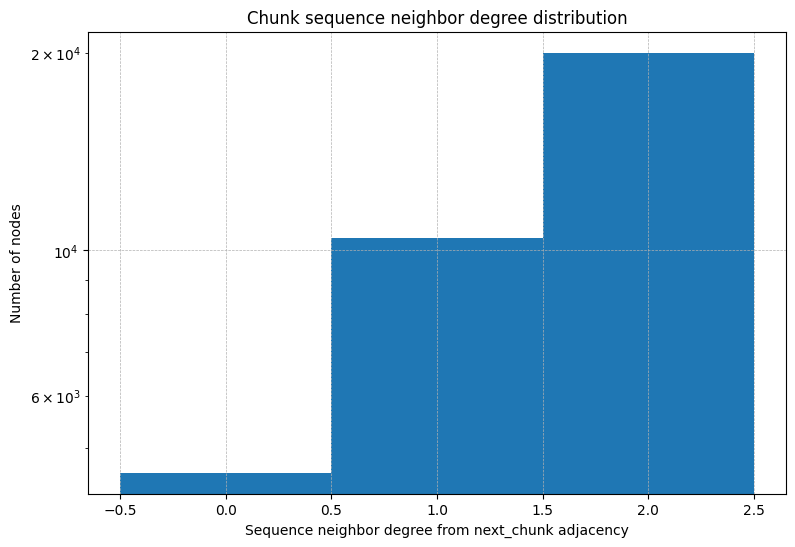

In [15]:
# cell 15
# Plot histogram of chunk sequence neighbor degree.
# This shows how many adjacent chunks each chunk has inside the same Wikipedia title.

plot_linear_hist(
    values=chunk_sequence_neighbor_degree,
    title="Chunk sequence neighbor degree distribution",
    xlabel="Sequence neighbor degree from next_chunk adjacency",
    bins=np.arange(chunk_sequence_neighbor_degree.max() + 2) - 0.5,
    log_y=True,
)

In [16]:
# cell 16
# Load entity and chunk labels only for displaying top-degree nodes.

entity_id_to_text = {}

with open(ENTITY_NODES_JSONL_PATH, "r", encoding="utf-8") as f:
    for line in tqdm(f, desc="Loading entity labels"):
        if not line.strip():
            continue
        rec = json.loads(line)
        entity_id_to_text[int(rec["entity_id"])] = rec["entity"]

chunk_node_id_to_meta = {}

with open(CHUNK_TEXT_CATALOG_JSONL_PATH, "r", encoding="utf-8") as f:
    for line in tqdm(f, desc="Loading chunk labels"):
        if not line.strip():
            continue
        rec = json.loads(line)
        chunk_node_id_to_meta[int(rec["chunk_node_id"])] = {
            "chunk_id": rec["chunk_id"],
            "title": rec["title"],
            "token_count": rec.get("token_count"),
        }

print("Loaded entity labels:", len(entity_id_to_text))
print("Loaded chunk labels:", len(chunk_node_id_to_meta))

if len(entity_id_to_text) != num_entities:
    raise RuntimeError("Entity label count does not match number of entity nodes.")

if len(chunk_node_id_to_meta) != num_chunks:
    raise RuntimeError("Chunk label count does not match number of chunk nodes.")

Loading entity labels: 0it [00:00, ?it/s]

Loading chunk labels: 0it [00:00, ?it/s]

Loaded entity labels: 327873
Loaded chunk labels: 35029


,rank,entity_id,entity,total_degree,relation_out_degree,relation_in_degree,fact_out_degree
0,1,69,united states,4378,477,2897,1004
1,2,1120,2010,1850,32,1350,468
2,3,2079,donald trump,1777,1092,242,443
3,4,1541,2008,1736,14,1307,415
4,5,2528,2007,1688,5,1291,392
5,6,760,london,1673,72,1212,389
6,7,830,2006,1640,8,1247,385
7,8,1411,2011,1608,10,1213,385
8,9,642,2009,1601,10,1185,406
9,10,1225,2012,1561,11,1159,391


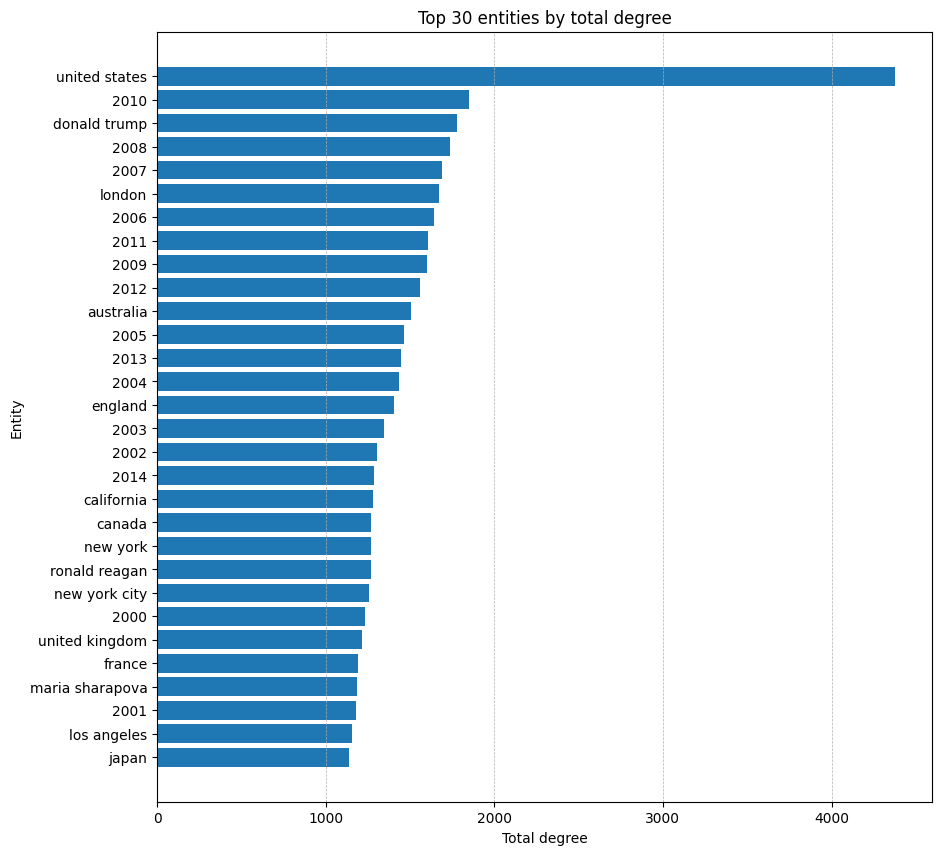

In [17]:
# cell 17
# Show and plot top entity nodes by total degree.

TOP_K = 30

top_entity_ids = np.argsort(-entity_total_degree)[:TOP_K]

top_entities_df = pd.DataFrame([
    {
        "rank": rank + 1,
        "entity_id": int(entity_id),
        "entity": entity_id_to_text.get(int(entity_id), ""),
        "total_degree": int(entity_total_degree[entity_id]),
        "relation_out_degree": int(entity_relation_out_degree[entity_id]),
        "relation_in_degree": int(entity_relation_in_degree[entity_id]),
        "fact_out_degree": int(entity_fact_out_degree[entity_id]),
    }
    for rank, entity_id in enumerate(top_entity_ids)
])

display(top_entities_df)

plot_df = top_entities_df.iloc[::-1]

plt.figure(figsize=(10, 10))
plt.barh(plot_df["entity"], plot_df["total_degree"])
plt.xlabel("Total degree")
plt.ylabel("Entity")
plt.title(f"Top {TOP_K} entities by total degree")
plt.grid(True, axis="x", linestyle="--", linewidth=0.5)

plt.show()

,rank,chunk_node_id,chunk_id,title,token_count,total_degree,fact_in_degree,sequence_neighbor_degree
0,1,12279,hotpotqa_chunk_00012280,Tamika Catchings,430,32,30,2
1,2,28638,hotpotqa_chunk_00028639,INXS,472,32,30,2
2,3,7470,hotpotqa_chunk_00007471,French Canadians,460,32,30,2
3,4,7469,hotpotqa_chunk_00007470,French Canadians,512,32,30,2
4,5,30954,hotpotqa_chunk_00030955,Dee Snider,454,32,30,2
5,6,29803,hotpotqa_chunk_00029804,Greg Patton,435,32,30,2
6,7,23343,hotpotqa_chunk_00023344,List of Lab Rats characters,451,32,30,2
7,8,10291,hotpotqa_chunk_00010292,John Bowman (pioneer),465,32,30,2
8,9,9749,hotpotqa_chunk_00009750,United States Army,473,32,30,2
9,10,6651,hotpotqa_chunk_00006652,Kalākaua,413,32,30,2


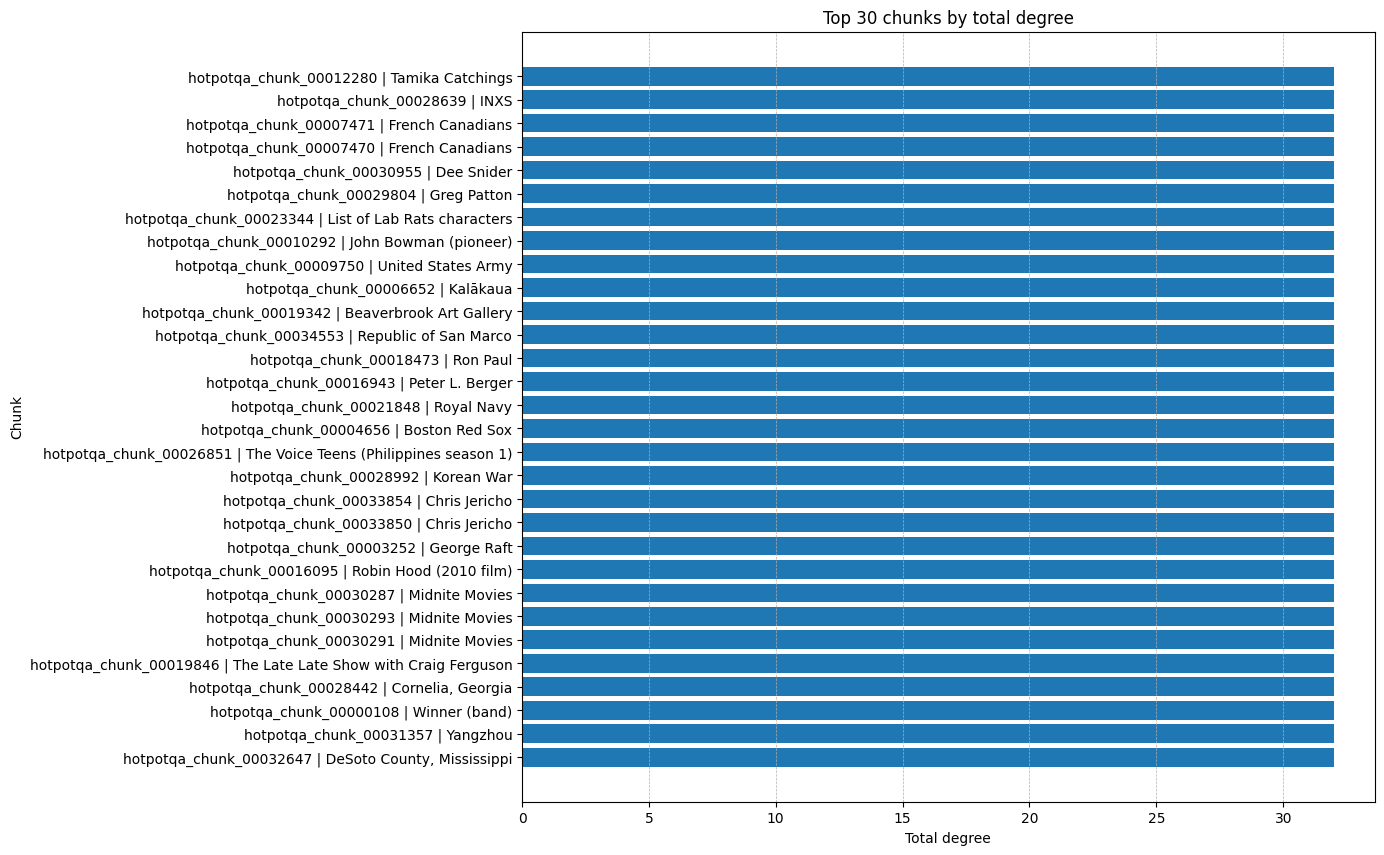

In [18]:
# cell 18
# Show and plot top chunk nodes by total degree.

TOP_K = 30

top_chunk_ids = np.argsort(-chunk_total_degree)[:TOP_K]

top_chunks_df = pd.DataFrame([
    {
        "rank": rank + 1,
        "chunk_node_id": int(chunk_node_id),
        "chunk_id": chunk_node_id_to_meta[int(chunk_node_id)]["chunk_id"],
        "title": chunk_node_id_to_meta[int(chunk_node_id)]["title"],
        "token_count": chunk_node_id_to_meta[int(chunk_node_id)]["token_count"],
        "total_degree": int(chunk_total_degree[chunk_node_id]),
        "fact_in_degree": int(chunk_fact_in_degree[chunk_node_id]),
        "sequence_neighbor_degree": int(chunk_sequence_neighbor_degree[chunk_node_id]),
    }
    for rank, chunk_node_id in enumerate(top_chunk_ids)
])

display(top_chunks_df)

plot_df = top_chunks_df.iloc[::-1].copy()
plot_df["label"] = plot_df["chunk_id"] + " | " + plot_df["title"].astype(str)

plt.figure(figsize=(11, 10))
plt.barh(plot_df["label"], plot_df["total_degree"])
plt.xlabel("Total degree")
plt.ylabel("Chunk")
plt.title(f"Top {TOP_K} chunks by total degree")
plt.grid(True, axis="x", linestyle="--", linewidth=0.5)

plt.show()

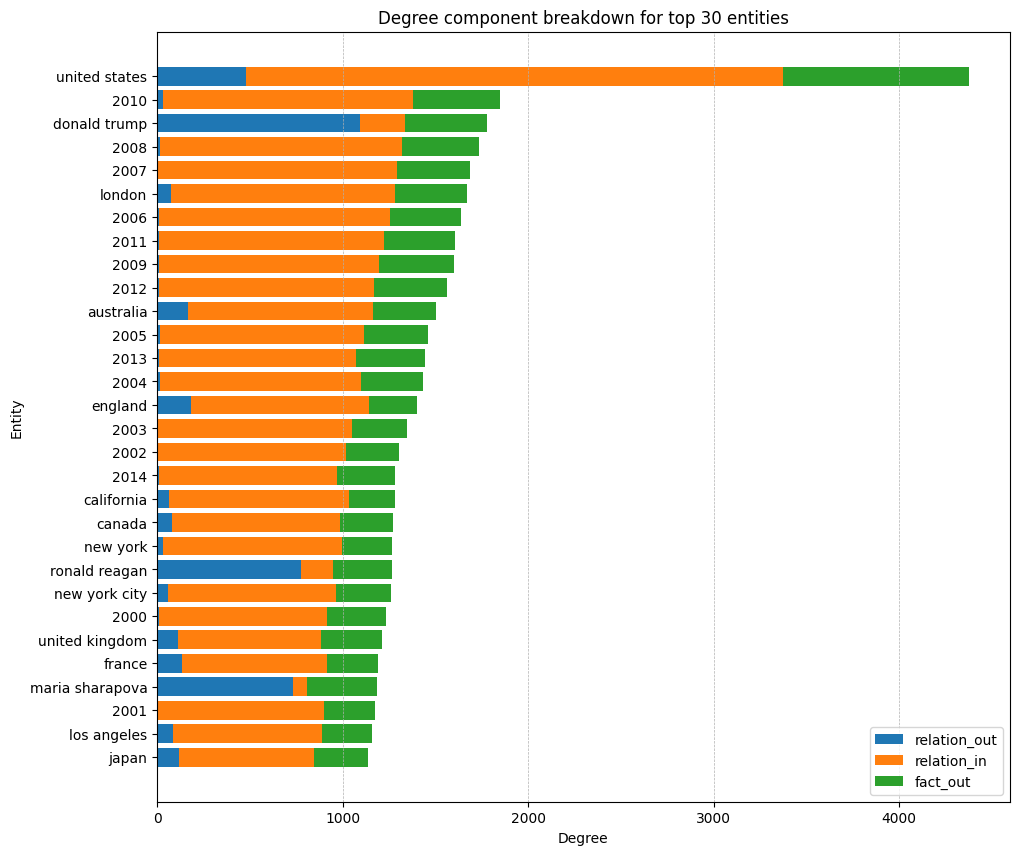

In [19]:
# cell 19
# Plot degree component breakdown for top entities.

component_df = top_entities_df.copy()
component_df = component_df.iloc[::-1]

labels = component_df["entity"].tolist()
relation_out = component_df["relation_out_degree"].to_numpy()
relation_in = component_df["relation_in_degree"].to_numpy()
fact_out = component_df["fact_out_degree"].to_numpy()

y_pos = np.arange(len(labels))

plt.figure(figsize=(11, 10))
plt.barh(y_pos, relation_out, label="relation_out")
plt.barh(y_pos, relation_in, left=relation_out, label="relation_in")
plt.barh(y_pos, fact_out, left=relation_out + relation_in, label="fact_out")

plt.yticks(y_pos, labels)
plt.xlabel("Degree")
plt.ylabel("Entity")
plt.title(f"Degree component breakdown for top {TOP_K} entities")
plt.legend()
plt.grid(True, axis="x", linestyle="--", linewidth=0.5)

plt.show()

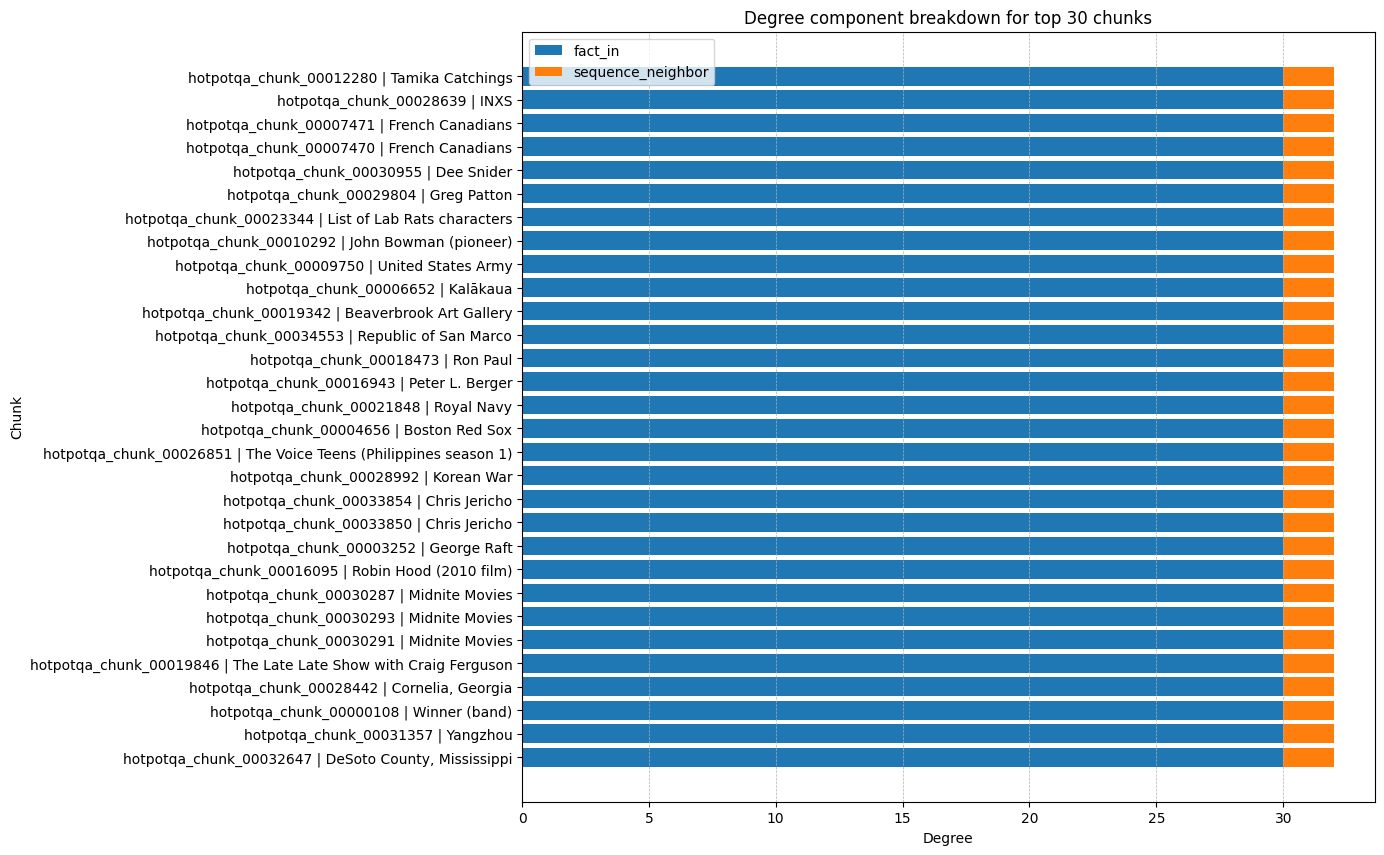

In [20]:
# cell 20
# Plot degree component breakdown for top chunks.

component_df = top_chunks_df.copy()
component_df = component_df.iloc[::-1]
component_df["label"] = component_df["chunk_id"] + " | " + component_df["title"].astype(str)

labels = component_df["label"].tolist()
fact_in = component_df["fact_in_degree"].to_numpy()
sequence_deg = component_df["sequence_neighbor_degree"].to_numpy()

y_pos = np.arange(len(labels))

plt.figure(figsize=(11, 10))
plt.barh(y_pos, fact_in, label="fact_in")
plt.barh(y_pos, sequence_deg, left=fact_in, label="sequence_neighbor")

plt.yticks(y_pos, labels)
plt.xlabel("Degree")
plt.ylabel("Chunk")
plt.title(f"Degree component breakdown for top {TOP_K} chunks")
plt.legend()
plt.grid(True, axis="x", linestyle="--", linewidth=0.5)

plt.show()

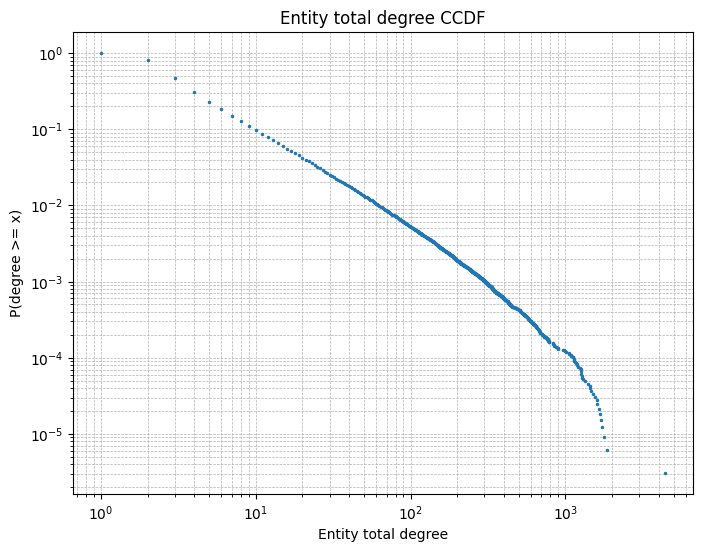

In [21]:
# cell 21
# Plot CCDF of entity total degree.
# This is useful for seeing hub-heavy behavior.

values = np.asarray(entity_total_degree, dtype=np.int64)
positive = np.sort(values[values > 0])

unique_degrees, counts = np.unique(positive, return_counts=True)
ccdf = np.cumsum(counts[::-1])[::-1] / positive.size

plt.figure(figsize=(8, 6))
plt.plot(unique_degrees, ccdf, marker=".", linestyle="none", markersize=3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Entity total degree")
plt.ylabel("P(degree >= x)")
plt.title("Entity total degree CCDF")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()

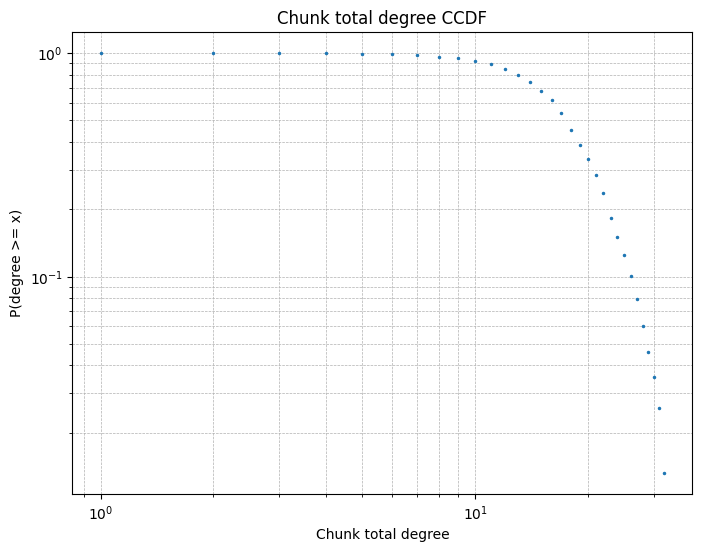

In [22]:
# cell 22
# Plot CCDF of chunk total degree.

values = np.asarray(chunk_total_degree, dtype=np.int64)
positive = np.sort(values[values > 0])

unique_degrees, counts = np.unique(positive, return_counts=True)
ccdf = np.cumsum(counts[::-1])[::-1] / positive.size

plt.figure(figsize=(8, 6))
plt.plot(unique_degrees, ccdf, marker=".", linestyle="none", markersize=3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Chunk total degree")
plt.ylabel("P(degree >= x)")
plt.title("Chunk total degree CCDF")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()

In [23]:
# cell 23
# Print final summary only in notebook output.

print("KG analysis finished. Nothing was saved.")

print("\nMain counts:")
print("Entity nodes:", f"{num_entities:,}")
print("Chunk nodes:", f"{num_chunks:,}")
print("Relation edges:", f"{int(rel_edge_index.shape[1]):,}")
print("Fact edges:", f"{int(fact_edge_index.shape[1]):,}")
print("Next chunk edges:", f"{int(next_edge_index.shape[1]):,}")
print("Prev chunk edges:", f"{int(prev_edge_index.shape[1]):,}")

print("\nEntity total degree summary:")
display(pd.DataFrame([describe_degree_array(entity_total_degree)]).T.rename(columns={0: "value"}))

print("\nChunk total degree summary:")
display(pd.DataFrame([describe_degree_array(chunk_total_degree)]).T.rename(columns={0: "value"}))

KG analysis finished. Nothing was saved.

Main counts:
Entity nodes: 327,873
Chunk nodes: 35,029
Relation edges: 692,402
Fact edges: 559,959
Next chunk edges: 25,219
Prev chunk edges: 25,219

Entity total degree summary:


,value
num_nodes,327873.000000
zero_degree_nodes,0.000000
nonzero_degree_nodes,327873.000000
min,1.000000
max,4378.000000
mean,5.931452
median,2.000000
p90,9.000000
p95,17.000000
p99,62.000000



Chunk total degree summary:


,value
num_nodes,35029.000000
zero_degree_nodes,2.000000
nonzero_degree_nodes,35027.000000
min,0.000000
max,32.000000
mean,17.425476
median,17.000000
p90,26.000000
p95,28.000000
p99,32.000000
